In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
traindf = pd.read_csv('DiamondPricess.csv')

In [3]:
traindf.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [4]:
traindf = traindf.drop(columns = 'Unnamed: 0')

In [5]:
traindf

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64
53940,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49
53941,0.71,Premium,F,SI1,59.8,62.0,2756,5.74,5.73,3.43


In [6]:
traindf.describe

<bound method NDFrame.describe of        carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64
53940   0.71    Premium     E     SI1   60.5   55.0   2756  5.79  5.74  3.49
53941   0.71    Premium     F     SI1   59.8   62.0   2756  5.74  5.73  3.43
53942   0.70  Very Good     E     VS2   60.5   59.0   2757  5.71  5.76  3.47

[53943 rows x 10 columns]>

In [7]:
traindf.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:
traindf.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [9]:
traindf['carat'] = traindf['carat'].fillna(traindf['carat'].mean())

In [10]:
traindf['cut'] = traindf['cut'].fillna(traindf['cut'].mode()[0])
traindf['cut'] = traindf['cut'].astype('category')

In [11]:
traindf['color'] = traindf['color'].fillna(traindf['color'].mode()[0])
traindf['color'] = traindf['color'].astype('category')

In [12]:
traindf['clarity'] = traindf['clarity'].fillna(traindf['clarity'].mode()[0])
traindf['clarity'] = traindf['clarity'].astype('category')

In [13]:
traindf['depth'].skew()

np.float64(-0.0821872142471791)

In [14]:
traindf['depth'] = traindf['depth'].fillna(traindf['depth'].mean())

In [15]:
traindf['table'].skew()

np.float64(0.796835977541281)

In [16]:
traindf['table'] = traindf['table'].fillna(traindf['table'].mean())

In [17]:
traindf['x'].skew()

np.float64(0.3786845346691225)

In [18]:
traindf['x'] = traindf['x'].fillna(traindf['x'].mean())

In [19]:
traindf['y'].skew()

np.float64(2.4342330799873726)

In [20]:
traindf['y'] = traindf['y'].fillna(traindf['y'].median())

In [21]:
traindf['z'].skew()

np.float64(1.522481020497441)

In [22]:
traindf['z'] = traindf['z'].fillna(traindf['z'].median())

In [23]:
traindf.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [24]:
traindf.drop_duplicates(keep='first', inplace = True)

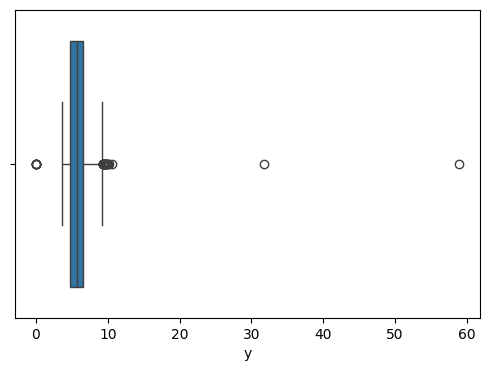

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['y'])
plt.show()

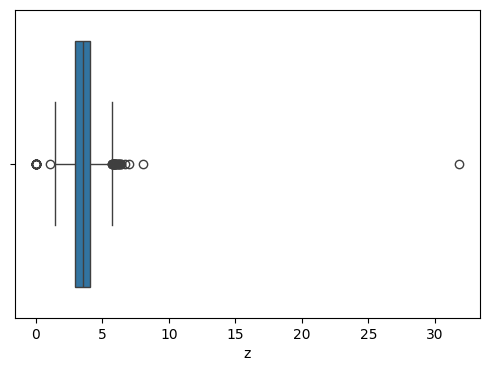

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['z'])
plt.show()

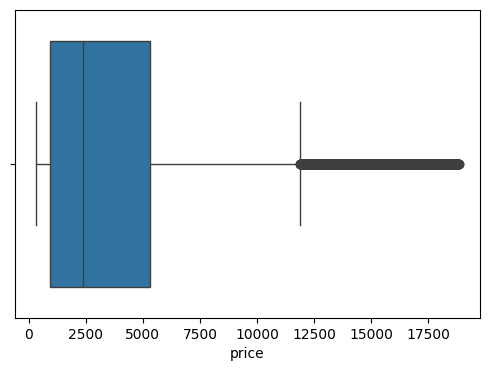

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['price'])
plt.show()

In [28]:
traindf.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [29]:
traindfcate = pd.get_dummies(traindf[['color','cut','clarity']],drop_first=True)

In [30]:
trainscaledpands = traindf[['carat','depth','table','x' ,'y' ,'z' ]]

In [31]:
trainingset = pd.concat([trainscaledpands,traindfcate], axis=1)

In [32]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    trainingset, traindf['price'],
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures same split every run
)

In [33]:
from sklearn.preprocessing import StandardScaler

num_cols = ['carat','depth','table','x','y','z']

scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])

In [34]:
print(type(x_train))          # should be pandas DataFrame (recommended)
print(x_train[num_cols].mean())  # should be ~0
print(x_train[num_cols].std())   # should be ~1 (roughly; pandas uses ddof=1)

<class 'pandas.DataFrame'>
carat   -1.149152e-16
depth    8.463442e-15
table    1.334073e-15
x       -3.520105e-16
y       -2.899298e-16
z       -7.396843e-16
dtype: float64
carat    1.000012
depth    1.000012
table    1.000012
x        1.000012
y        1.000012
z        1.000012
dtype: float64


In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = model.predict(x_test)

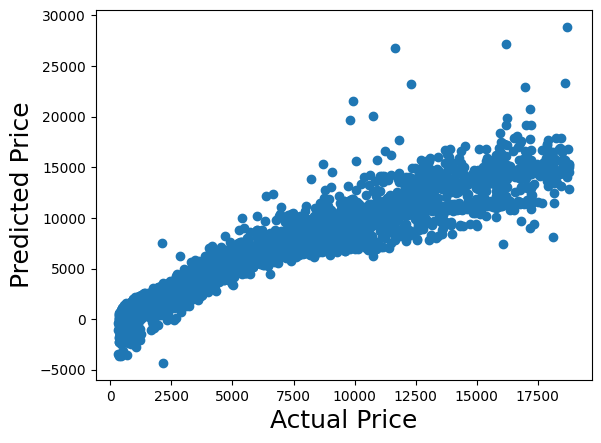

In [37]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Price',size=18)
plt.ylabel('Predicted Price',size=18)
plt.show()

In [38]:
r2 = model.score(x_test, y_test)

print("R²:", r2)

R²: 0.9202802581013383
